# Plummer tracer with free inner slope $\gamma_\star$

Held-out test of `chebconv_9params_plumgamma.py`, trained on
`9p_plumgamma`. The inference targets are exactly the seven
DM/DF parameters of the 8-parameter baseline; $\gamma_\star$
and $\log R_h$ enter as conditioning inputs, not targets.

The question this run answers is whether the DM posterior
stays honest once the light profile is no longer exactly
Plummer but its shape is known. This prior also keeps
$\beta_0 \leq 0$ and $\log r_a \geq 0$, so unlike the
8-parameter baseline every galaxy here satisfies the
slope-anisotropy theorem and its labels mean what they say.

**What is tested.** Every galaxy below comes from `data.8.h5`, the one
shard the training config never read (`num_datasets = 8` reads shards
0-7), so nothing here is a re-split of training data.

The model's own stochastic pre-transforms -- radial selection and
velocity uncertainty -- are applied exactly as in training. That matters
for the calibration claims: they hold for data drawn from the same
process the model was trained for, not for noiseless 6D truth.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, '/home/tvnguyen/projects/sbi_dsph/sbi_dsph_pipeline/npe')

import eval_utils as ev

ev.use_style()

PROJECT = '9p_plumgamma'
CHECKPOINT = 'last.ckpt'
N_TEST = 2000       # galaxies drawn from the held-out shard
N_SAMPLES = 1000    # posterior draws per galaxy

OUTDIR = os.environ.get(
    'EVAL_OUTDIR', f'/scratch/{os.environ["USER"]}/npe_eval/{PROJECT}')
os.makedirs(OUTDIR, exist_ok=True)
print(f'output -> {OUTDIR}')

output -> /scratch/tvnguyen/npe_eval/9p_plumgamma


## 1. Load the run and sample the posterior

In [2]:
run_dir = ev.find_run_dir(PROJECT)
model, config, norm_dict = ev.load_npe(run_dir, CHECKPOINT)

loader, shard = ev.load_test_set(config, norm_dict, max_graphs=N_TEST)
samples, truth = ev.sample_posterior(model, loader, num_samples=N_SAMPLES)

names = list(config.labels)
print(f'\nposterior {samples.shape}  truth {truth.shape}')
print(f'targets:      {names}')
print(f'conditioning: {list(config.get("cond_labels", []))}')

loaded last.ckpt (epoch 59)
[NPE] Flows built from scratch with 328,134 parameters



  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00,  6.88it/s]


100%|██████████| 1/1 [00:00<00:00,  6.85it/s]


Seed set to 0


...


 88%|████████▊ | 14/16 [00:12<00:01,  1.19it/s]


 94%|█████████▍| 15/16 [00:12<00:00,  1.19it/s]


100%|██████████| 16/16 [00:13<00:00,  1.34it/s]


100%|██████████| 16/16 [00:13<00:00,  1.19it/s]


posterior (2000, 1000, 7)  truth (2000, 7)
targets:      ['dm_alpha', 'dm_beta', 'dm_gamma', 'dm_log_rdm', 'dm_log_rho0', 'df_beta0', 'df_log_ra']
conditioning: ['stellar_log_rhalf_kpc', 'stellar_gamma']


## 2. An example corner plot

One test galaxy, its posterior against the truth (red). Contours are the
68% and 95% credible regions.

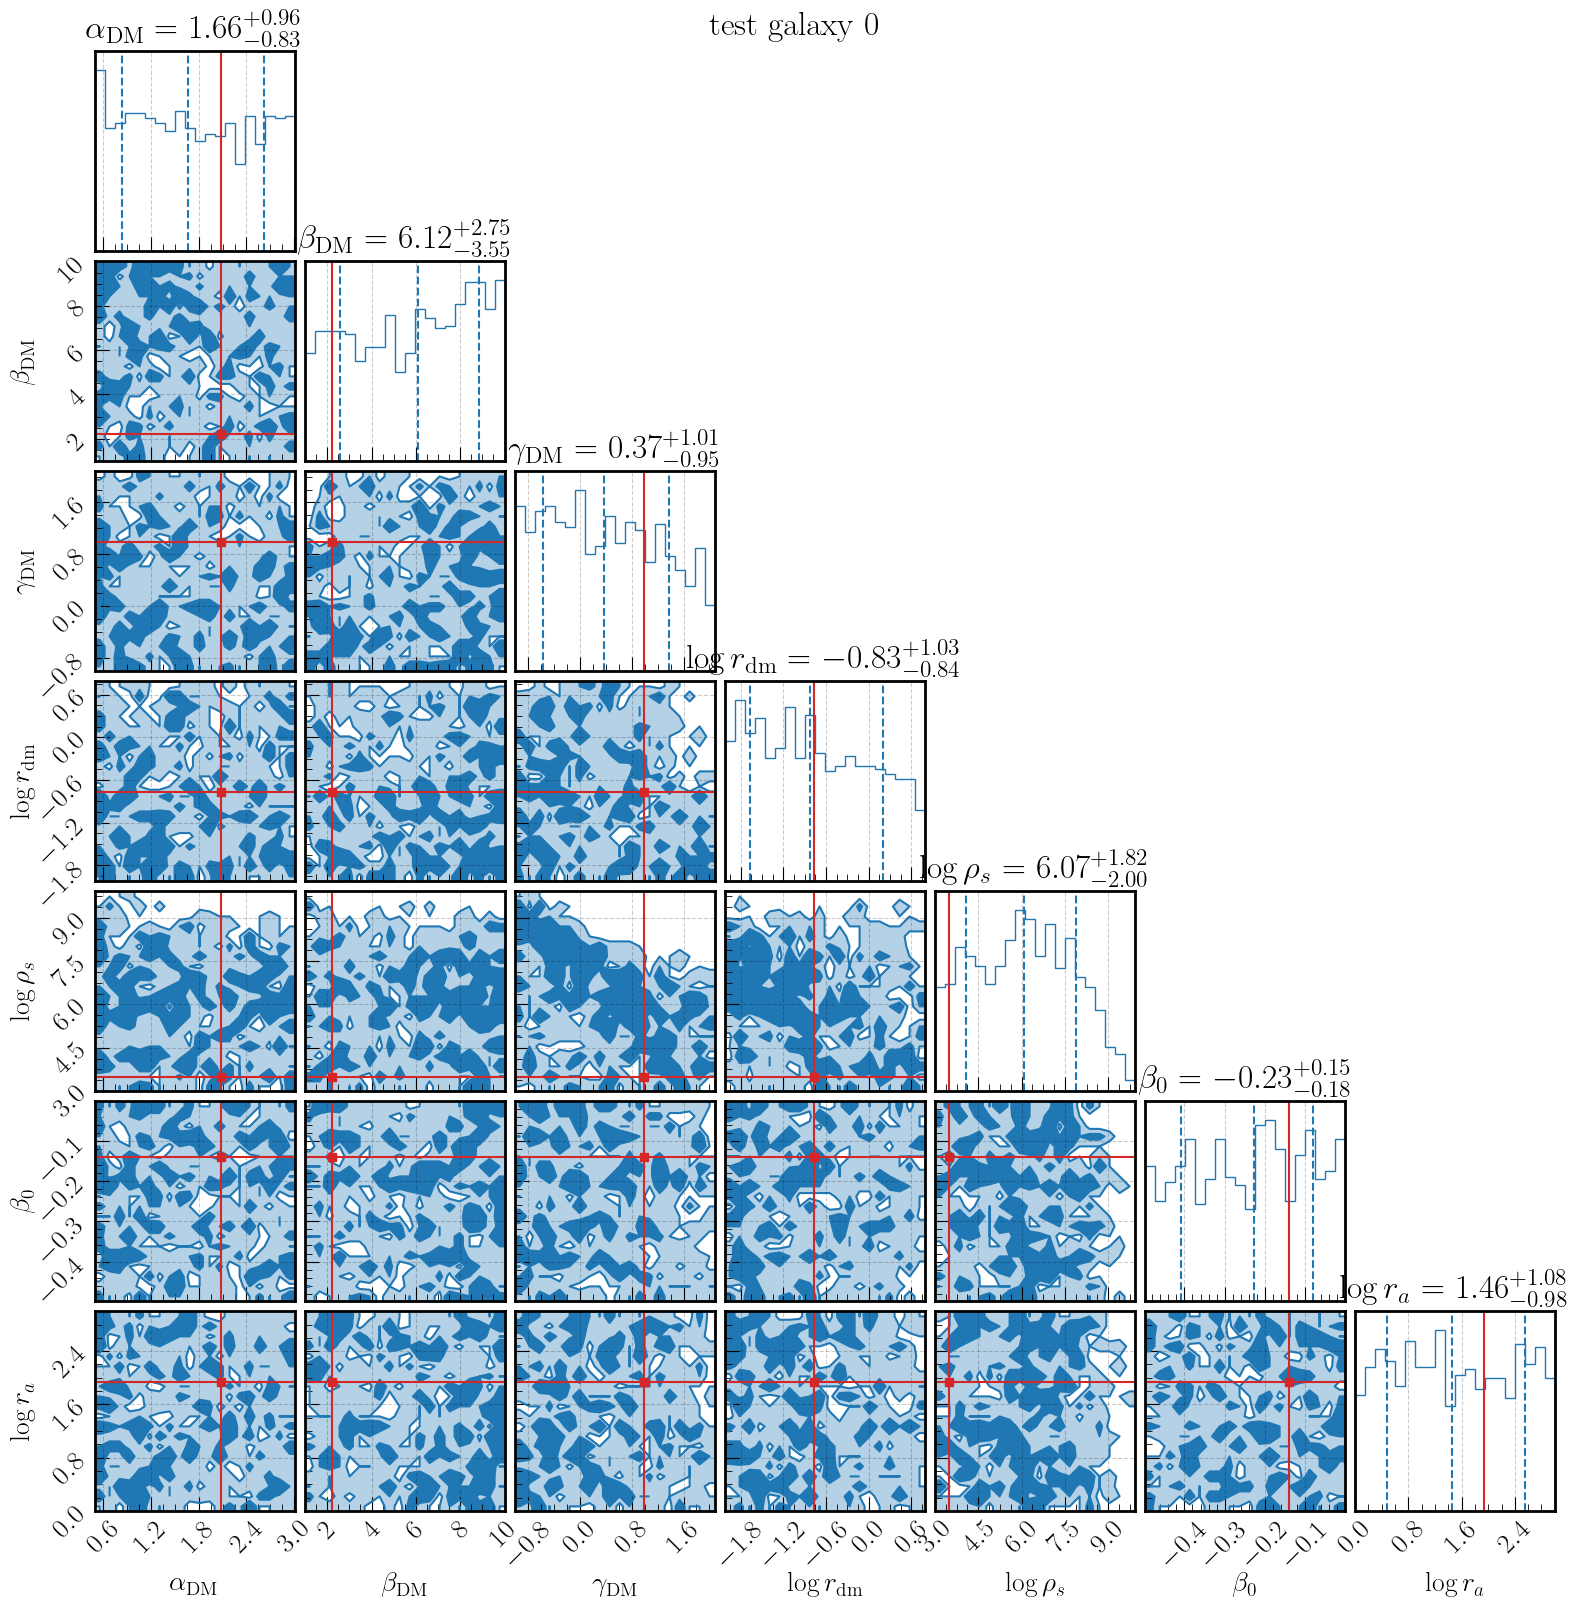

In [3]:
fig = ev.plot_corner(
    samples, truth, names, index=0,
    out_path=f'{OUTDIR}/fig1_corner_example.png')
plt.show()

## 3. Posterior median vs truth

Error bars are the 68% credible interval. `width_over_prior` is the mean
interval width divided by the full prior range -- the honest measure of
how much each parameter was actually learned. A value near 1 means the
posterior is telling you roughly what the prior already did.

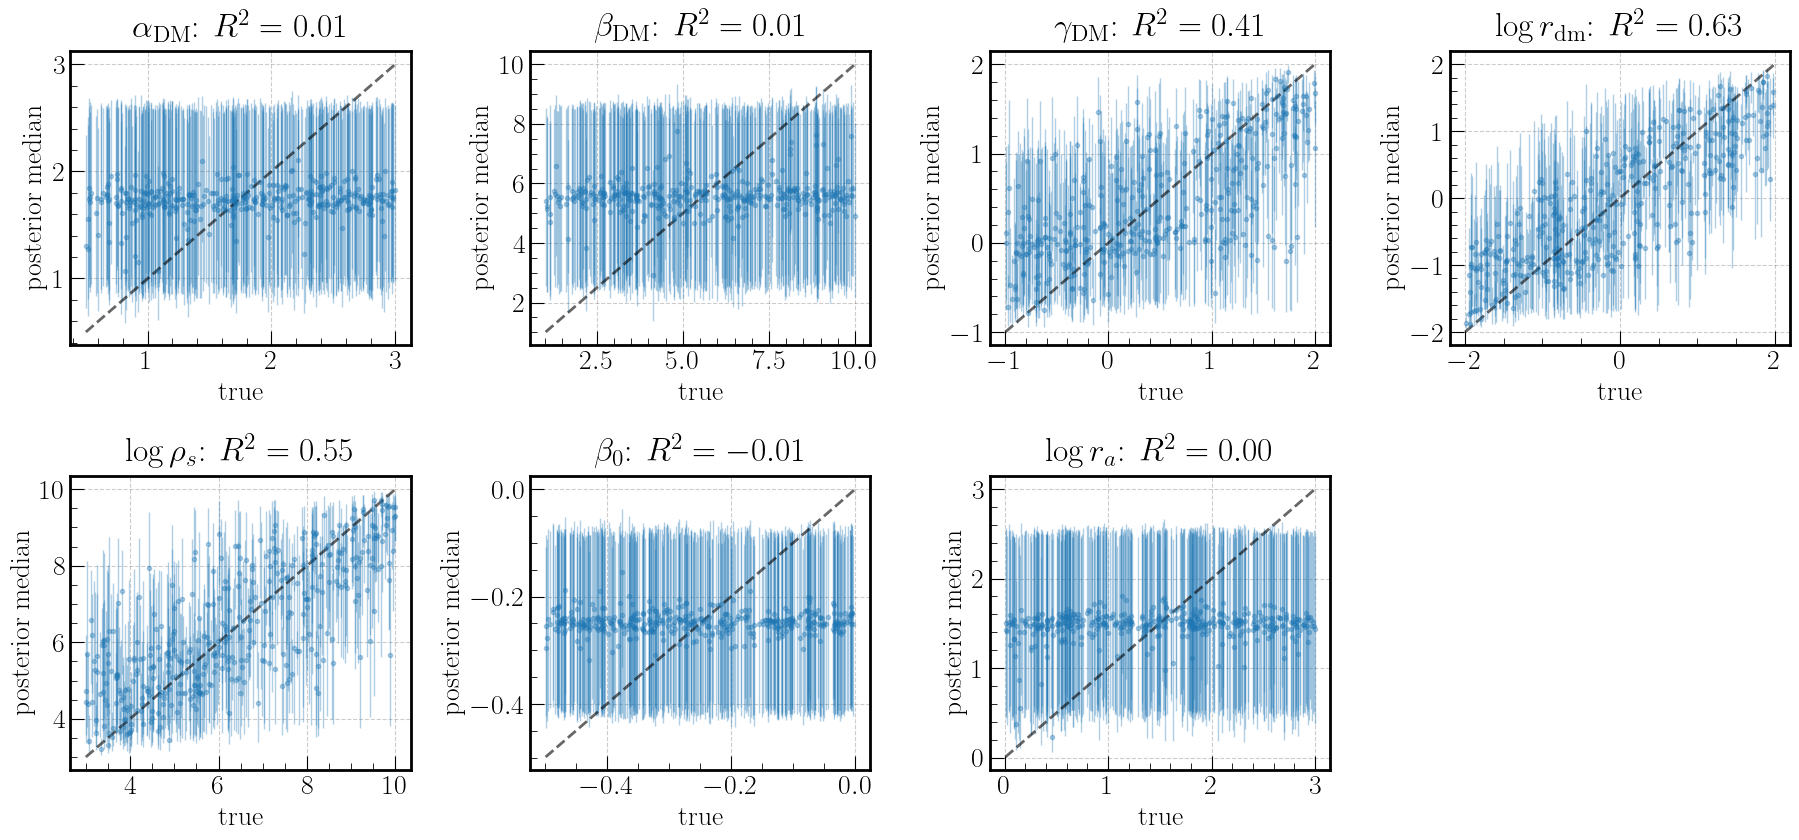

parameter                     R2     bias  scatter  68% width   /prior
dm_alpha                   0.009   -0.009    0.724      1.681     0.67
dm_beta                    0.005   -0.083    2.548      5.925     0.66
dm_gamma                   0.407   -0.010    0.651      1.367     0.46
dm_log_rdm                 0.634   -0.044    0.670      1.465     0.37
dm_log_rho0                0.546    0.030    1.310      2.653     0.38
df_beta0                  -0.005    0.005    0.144      0.337     0.68
df_log_ra                  0.004   -0.009    0.877      2.029     0.68


In [4]:
fig, stats = ev.plot_pred_vs_true(
    samples, truth, names, out_path=f'{OUTDIR}/fig2_pred_vs_true.png')
plt.show()

print(f'{"parameter":<24s} {"R2":>7s} {"bias":>8s} '
      f'{"scatter":>8s} {"68% width":>10s} {"/prior":>8s}')
for name, s in stats.items():
    print(f'{name:<24s} {s["r2"]:7.3f} {s["bias"]:8.3f} '
          f'{s["scatter"]:8.3f} {s["width68"]:10.3f} '
          f'{s["width_over_prior"]:8.2f}')

## 4. Calibration I -- TARP

TARP tests the *joint* posterior: it draws random reference points and
checks that credible regions contain the truth as often as they claim.
A calibrated model tracks the diagonal. Bands are 1-3 sigma bootstrap.


  0%|          | 0/100 [00:00<?, ?it/s]


  1%|          | 1/100 [00:00<01:17,  1.28it/s]


  2%|▏         | 2/100 [00:00<00:43,  2.24it/s]


  3%|▎         | 3/100 [00:01<00:28,  3.37it/s]


  4%|▍         | 4/100 [00:01<00:21,  4.41it/s]

...


 97%|█████████▋| 97/100 [00:13<00:00,  8.36it/s]


 98%|█████████▊| 98/100 [00:13<00:00,  8.40it/s]


 99%|█████████▉| 99/100 [00:13<00:00,  8.41it/s]


100%|██████████| 100/100 [00:14<00:00,  8.40it/s]


100%|██████████| 100/100 [00:14<00:00,  7.10it/s]

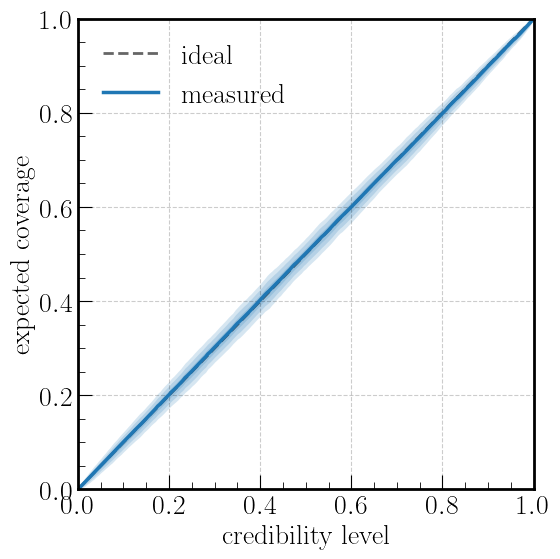

max |coverage - credibility| = 0.0030


In [5]:
fig, tarp_dev = ev.plot_tarp(
    samples, truth, out_path=f'{OUTDIR}/fig3_tarp.png')
plt.show()
print(f'max |coverage - credibility| = {tarp_dev:.4f}')

## 5. Calibration II -- rank-based marginals

For each parameter, the rank of the truth among the posterior draws.
Uniform means calibrated; a U shape means the posterior is too narrow, a
dome means too wide, and a slope means it is biased. The grey band is
the 2-sigma binomial spread expected from a uniform histogram, and
chi2_nu is the reduced chi-square against uniform (1 is ideal).

TARP tests the joint, this tests each marginal -- a model can pass one
and fail the other, so they are worth reading together.

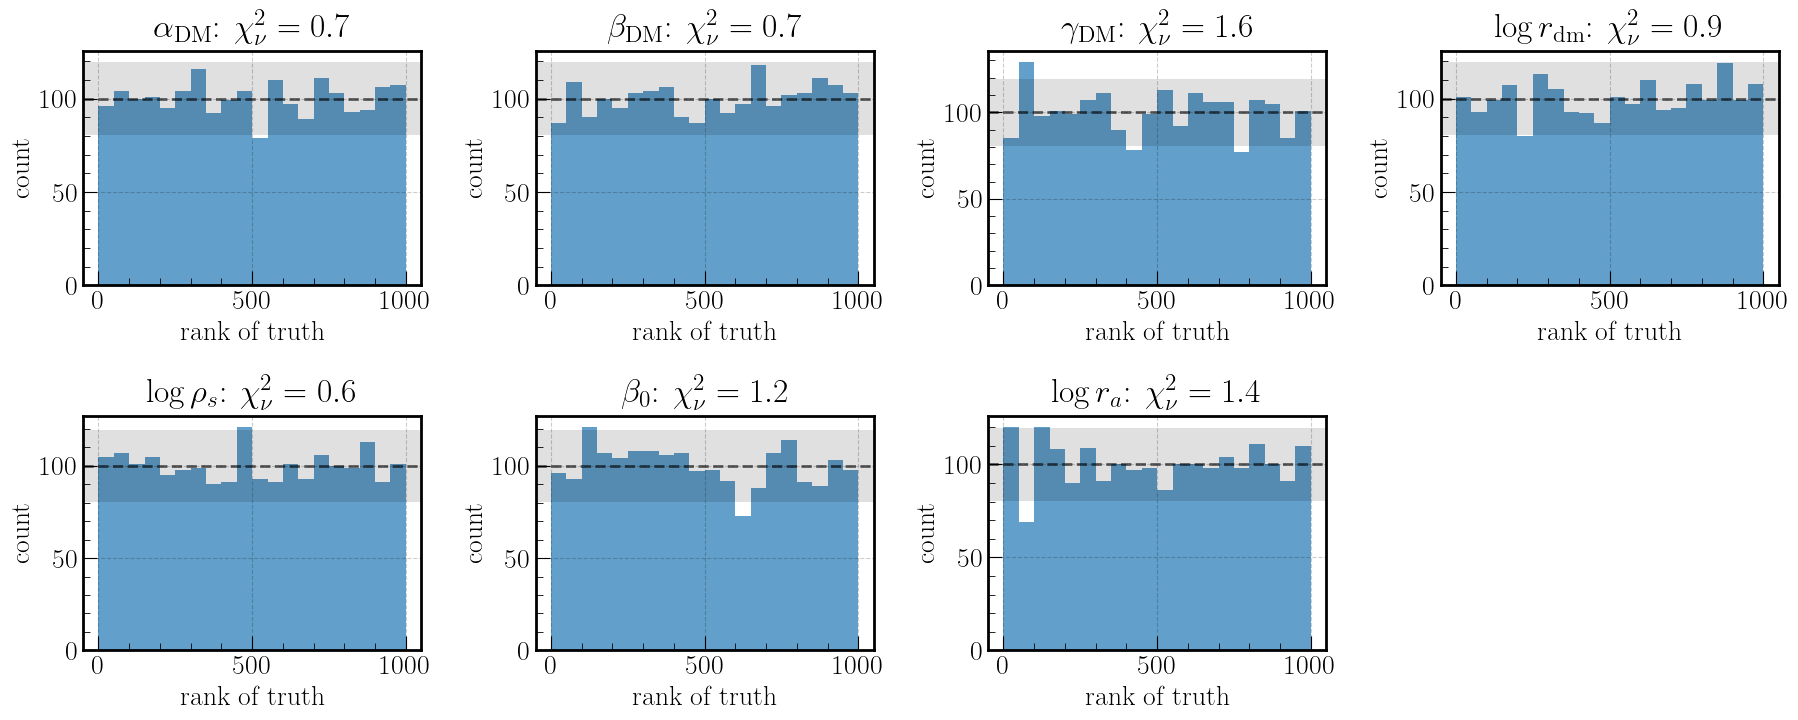

dm_gamma                 chi2_nu =   1.62
df_log_ra                chi2_nu =   1.38
df_beta0                 chi2_nu =   1.15
dm_log_rdm               chi2_nu =   0.86
dm_alpha                 chi2_nu =   0.73
dm_beta                  chi2_nu =   0.69
dm_log_rho0              chi2_nu =   0.64


In [6]:
fig, chi2 = ev.plot_rank_marginals(
    samples, truth, names, out_path=f'{OUTDIR}/fig4_rank_marginals.png')
plt.show()
for name, c in sorted(chi2.items(), key=lambda kv: -kv[1]):
    print(f'{name:<24s} chi2_nu = {c:6.2f}')

## 6. Calibration III -- correlations between parameters

Sections 3 and 5 look at one parameter at a time, and TARP collapses the
joint to a single scalar. All three can pass while the posterior states
the wrong *correlation*. On a conjugate-Gaussian control where the true
posterior correlation was deliberately zeroed, the 1-D rank histograms
stayed at chi2_nu = 0.70 and 1.45 -- perfectly healthy -- while the
difference-direction test below rose to 10.0.

**Left panel** is the posterior correlation averaged over test galaxies:
descriptive, it says which degeneracies the model reports. **Right
panel** whitens each galaxy's error by its own posterior covariance, so
a correctly-shaped posterior gives the identity; off-diagonal structure
means the reported correlation is wrong.

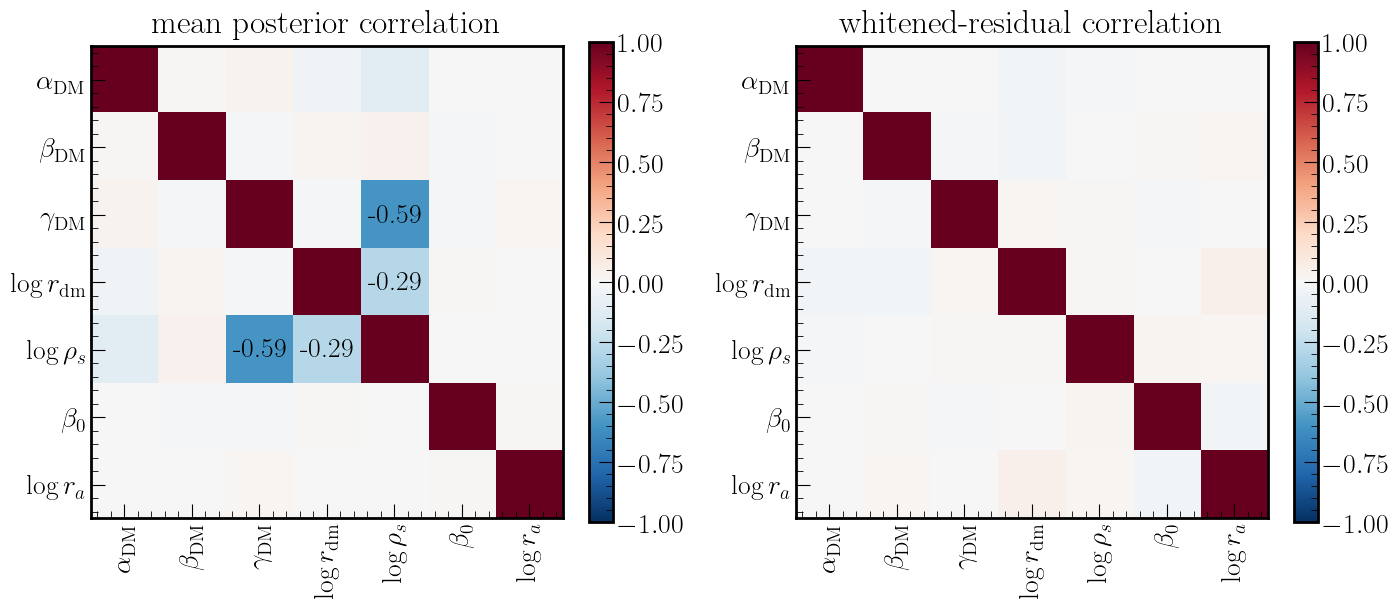

largest |off-diagonal| of whitened residual correlation: 0.052
whitened variance per parameter (1.0 = calibrated width):
  dm_alpha                 1.012
  dm_beta                  1.008
  dm_gamma                 0.975
  dm_log_rdm               1.016
  dm_log_rho0              1.019
  df_beta0                 1.015
  df_log_ra                1.039

strongest degeneracies the posterior reports:
  dm_gamma               dm_log_rho0            r = -0.59
  dm_log_rdm             dm_log_rho0            r = -0.29
  dm_alpha               dm_log_rho0            r = -0.11
  dm_beta                dm_log_rho0            r = +0.04
  dm_alpha               dm_log_rdm             r = -0.04
  dm_alpha               dm_gamma               r = +0.03


In [7]:
fig, corr = ev.plot_correlation_matrices(
    samples, truth, names, out_path=f'{OUTDIR}/fig5_correlations.png')
plt.show()
print(f'largest |off-diagonal| of whitened residual correlation: '
      f'{corr["max_offdiag"]:.3f}')
print('whitened variance per parameter (1.0 = calibrated width):')
for name, v in zip(names, corr['whitened_var']):
    print(f'  {name:<24s} {v:.3f}')

pc = corr['posterior_corr']
iu = np.triu_indices(len(names), k=1)
order = np.argsort(-np.abs(pc[iu]))
print()
print('strongest degeneracies the posterior reports:')
for k in order[:6]:
    i, j = iu[0][k], iu[1][k]
    print(f'  {names[i]:<22s} {names[j]:<22s} r = {pc[i, j]:+.2f}')

The whitening above assumes the posterior is roughly Gaussian. This next
test does not: if the joint posterior is calibrated, the rank of the
truth is uniform along **any** fixed direction in parameter space, not
only along the coordinate axes. Squeezing or stretching the
`theta_i - theta_j` direction is exactly what a mis-stated correlation
does, while leaving both 1-D marginals untouched.

Difference directions are below the diagonal, sum directions above it,
and the single-parameter values on the diagonal (these match section 5).

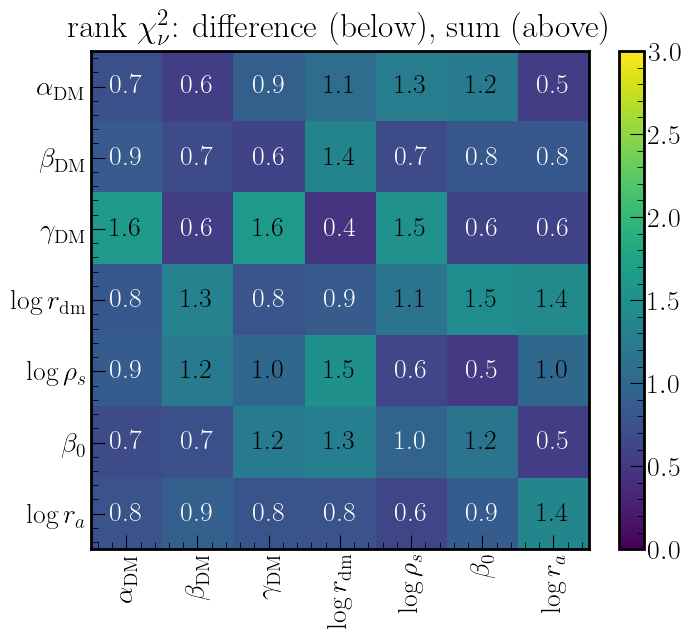

worst combination: dm_gamma vs dm_alpha  chi2_nu = 1.63
200 random directions: median chi2_nu 0.94, max 2.29, fraction above 2.0 = 0.01


In [8]:
fig, pair = ev.plot_pairwise_rank_calibration(
    samples, truth, names,
    out_path=f'{OUTDIR}/fig6_pairwise_rank.png')
plt.show()
w = pair['worst_pair']
print(f'worst combination: {w[0]} vs {w[1]}  chi2_nu = {w[2]:.2f}')
print(f'200 random directions: median chi2_nu '
      f'{pair["random_median"]:.2f}, max {pair["random_max"]:.2f}, '
      f'fraction above 2.0 = {pair["random_frac_above_2"]:.2f}')

## 7. Calibration IV -- MIRA

MIRA is built like TARP but returns a single number, higher being
better and 1 the ceiling. It scores **calibration, not
informativeness**: a posterior that just returns the prior is perfectly
calibrated and scores as well as a sharp one. That is why the prior
baseline below is a *reference*, not a floor -- if the model matches it,
that means calibrated, and section 3's widths are what say whether the
posterior is also useful.

The two miscalibrated controls take the model's own posterior and
rescale it about its median by 3x and 1/3. Both should score clearly
lower, and how much lower sets the scale for reading the model's number.

In [9]:
mira = ev.mira_scores(samples, truth, num_runs=100)
for name, (score, std) in mira.items():
    print(f'{name:<20s} {score:.4f} +/- {std:.4f}')

model                0.6669 +/- 0.0057
model x3 broader     0.5200 +/- 0.0072
model /3 sharper     0.5525 +/- 0.0064
prior baseline       0.6677 +/- 0.0046


## Summary

In [10]:
worst = max(chi2.items(), key=lambda kv: kv[1])
tightest = min(stats.items(), key=lambda kv: kv[1]['width_over_prior'])
loosest = max(stats.items(), key=lambda kv: kv[1]['width_over_prior'])

print(f'run           {run_dir.name} ({CHECKPOINT})')
print(f'test set      {truth.shape[0]} galaxies from data.{shard}.h5')
print(f'TARP          max deviation {tarp_dev:.4f}')
print(f'ranks         worst chi2_nu {worst[1]:.2f} ({worst[0]})')
print(f'correlations  max |off-diag| {corr["max_offdiag"]:.3f}; '
      f'worst pair {pair["worst_pair"][2]:.2f} '
      f'({pair["worst_pair"][0]} vs {pair["worst_pair"][1]})')
print(f'random dirs   median chi2_nu {pair["random_median"]:.2f}, '
      f'max {pair["random_max"]:.2f}')
print(f'MIRA          {mira["model"][0]:.4f} vs '
      f'{mira["prior baseline"][0]:.4f} prior, '
      f'{mira["model x3 broader"][0]:.4f} broadened')
print(f'best measured {tightest[0]} '
      f'({tightest[1]["width_over_prior"]:.2f} of prior range)')
print(f'least        {loosest[0]} '
      f'({loosest[1]["width_over_prior"]:.2f} of prior range)')

run           ajw2fp57 (last.ckpt)
test set      2000 galaxies from data.8.h5
TARP          max deviation 0.0030
ranks         worst chi2_nu 1.62 (dm_gamma)
correlations  max |off-diag| 0.052; worst pair 1.63 (dm_gamma vs dm_alpha)
random dirs   median chi2_nu 0.94, max 2.29
MIRA          0.6669 vs 0.6677 prior, 0.5200 broadened
best measured dm_log_rdm (0.37 of prior range)
least        df_log_ra (0.68 of prior range)
